<a href="https://colab.research.google.com/github/VilchisKarla/Procesos-Estocasticos/blob/main/Serpientes_escaleras_simu_analitico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

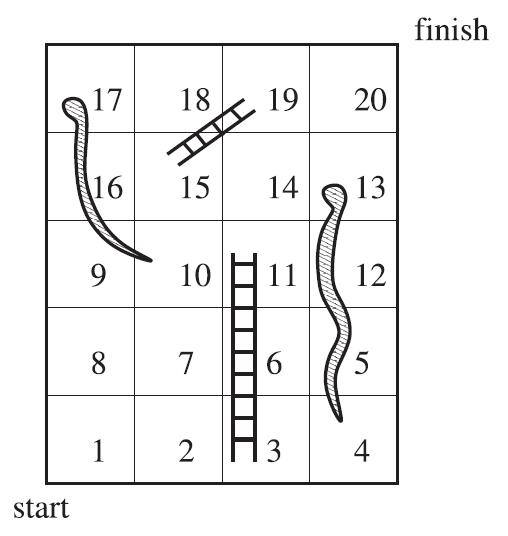

# Solución por simulación
Vilchis García Karla Ivonne


---



importar las paqueterías

In [2]:
import random as rd
from matplotlib  import pyplot as plt
import numpy as np
import  math

definimos nuestro dado

In [3]:
def dado():
    return np.random.randint(1,7)

definimos el juego

In [14]:
def partida():
    pos=0
    tiros=0
    tablero = {3: 11, 15: 19, 13: 4, 17: 10} #diccionario de las serpientes y escaleras
    while pos<20:
        tiro = dado()
        pos += tiro

        if pos in tablero:
           pos = tablero[pos]
        tiros += 1

    return tiros
print(partida())

5


experimento para ver cuántas  veces sedebe tirar el dado  para  ganar

In [15]:
def experimento(m):
    lista =[]
    for i in range(m):
        d = partida()
        lista.append(d)
    p=np.mean(np.array(lista))
    return p

L = experimento(10000)

print("media:", np.mean(L))
print("varianza:", np.var(L))

media: 7.0673
varianza: 0.0


7.051493554710774


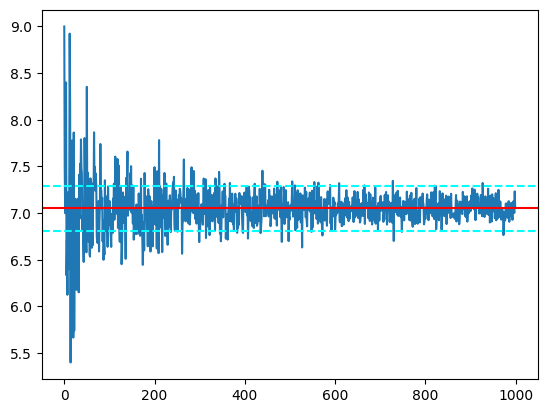

In [6]:
def exp(n):
  promedio=[]
  for i in range (n):
    promedio.append(experimento(i+1))
  return promedio

LM=exp(1000)
print(np.mean(LM))

plt.plot(LM)
plt.axhline(y=np.mean(LM), color='r', label="media:")
plt.axhline(y=np.mean(LM)+math.sqrt(np.var(LM)),color='cyan', linestyle='--', label="Varianza")
plt.axhline(y=np.mean(LM)-math.sqrt(np.var(LM)), color='cyan', linestyle='--')
plt.show()

# Solución analítica

importar las librerías que se usarán

In [7]:
import sympy as sp
from networkx.classes.function import edges
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import string

definir la matriz de transición correspondiente al tablero

In [8]:
P = sp.Matrix([
    [0, sp.Rational(1,6), 0, sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), 0, 0, 0, sp.Rational(1,6), 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), 0, 0, sp.Rational(1,6), 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, sp.Rational(1,6), 0, 0, sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, sp.Rational(1,6), 0, 0, 0, sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), 0, sp.Rational(1,6), 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, sp.Rational(1,6), 0, 0, 0, 0, sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6), 0, sp.Rational(1,6), 0, 0, 0, 0, sp.Rational(1,6), 0],
    [0, 0, 0, 0, sp.Rational(1,6), 0, 0, 0, 0, 0, sp.Rational(1,6), sp.Rational(1,6), 0, sp.Rational(1,6), 0, sp.Rational(1,6), 0, 0, sp.Rational(1,6), 0],
    [0, 0, 0, 0, sp.Rational(1,6), 0, 0, 0, sp.Rational(1,6), 0, 0, sp.Rational(1,6), 0, sp.Rational(1,6), 0, sp.Rational(1,6), 0, 0, sp.Rational(1,6), 0],
    [0, 0, 0, 0, sp.Rational(1,6), 0, 0, 0, sp.Rational(1,6), 0, 0, 0, 0, sp.Rational(1,6), 0, sp.Rational(1,6), 0, sp.Rational(1,6), sp.Rational(1,6), 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, sp.Rational(1,6), 0, 0, 0, 0, 0, 0, sp.Rational(1,6), 0, sp.Rational(1,6), sp.Rational(1,3), sp.Rational(1,6)],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, sp.Rational(1,6), 0, 0, 0, 0, 0, 0, sp.Rational(1,3), 0, sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6)],
    [0, 0, 0, 0, 0, 0, 0, 0, sp.Rational(1,2), 0, 0, 0, 0, 0, 0, 0, 0, sp.Rational(1,6), sp.Rational(1,6), sp.Rational(1,6)],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, sp.Rational(2,3), sp.Rational(1,6), sp.Rational(1,6)],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
])

P

Matrix([
[0, 1/6, 0, 1/6, 1/6, 1/6, 1/6,   0,   0,   0, 1/6,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0, 1/6, 1/6, 1/6, 1/6, 1/6,   0,   0, 1/6,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0,   0,   0,   0,   0,   0,   0,   0,   1,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6,   0,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0,   0,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0,   0, 1/6,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 0,   0, 1/6,   0,   0,   0, 1/6, 1/6, 1/6, 1/6, 0, 1/6, 0,   0, 0,   0,   0,   0],
[0,   0, 0,   0, 1/6,   0,   0,   0,   0, 1/6, 1/6, 1/6, 0, 1/6, 0,   0, 0,   0, 1/6,   0],
[0,   0, 0,   0, 1/6,   0,   0,   0,   0,   0, 1/6, 1/6, 0, 1/6, 0, 1/6, 0,   0, 1/6,   0],
[0,   0, 0,   0, 1/6,   0,   0,   0, 1/6,   0,   0, 1/6, 0, 1/6, 0, 1/6

hacer la descomposición canínica de la matriz

In [9]:
def construir_grafo(P):
    n = P.shape[0]
    G = nx.DiGraph()

    for i in range(n):
        for j in range(n):
            if P[i, j] > 0:
                G.add_edge(i,j, weight=P[i, j])  #arcos con su peso

    return G

#función para identificar las clases
def clases_comunicacion(G):
    return list(nx.strongly_connected_components(G))

#función para definir si es clase cerrada
def es_cerrada(P, clase):
    for i in clase:
        for j in range(P.shape[0]):
            if j not in clase and P[i, j] > 0:
                return False
    return True
#función para construir la matriz canónica y separar por bloques transitorios y recurrentes
def reordenar_y_bloques(P):
    G = construir_grafo(P)
    clases = list(nx.strongly_connected_components(G))

    transitorios = []
    recurrentes = []

    # Separar clases
    for c in clases:
        if es_cerrada(P, c):
            recurrentes.append(sorted(list(c)))
        else:
            transitorios.append(sorted(list(c)))

    # Sort transient and recurrent classes based on their first element for consistent ordering
    transitorios.sort(key=lambda x: x[0] if x else -1)  # Handle empty classes if any
    recurrentes.sort(key=lambda x: x[0] if x else -1)

    # Orden final
    orden = []

    for c in transitorios:
        orden.extend(c)

    for c in recurrentes:
        orden.extend(c)

    # Matriz reordenada
    P_new = P[np.ix_(orden, orden)]

    # EXTRAER BLOQUES

    # Tamaño de T
    size_T = sum(len(c) for c in transitorios)

    # Bloque
    if size_T > 0:
        T_block = P_new[:size_T, :size_T]
        print("\nMatriz T (transitoria):\n",'\n\n')
        print(np.array(T_block))
    else:
        print("\nNo hay estados transitorios")

    # Bloques R_i (cada clase recurrente)
    inicio = size_T

    for idx, clase in enumerate(recurrentes):
        size = len(clase)

        R_i = P_new[inicio:inicio+size, inicio:inicio+size]

        print(f"\nMatriz R_{idx+1} (clase {clase}):\n",'\n\n')
        sp.pprint(sp.Matrix(R_i))

        inicio += size

    return P_new, orden, transitorios, recurrentes,T_block

# SOLUCIÓN
P = np.array(P)

P_new, orden, T, R, Q = reordenar_y_bloques(P)
etiquetas = [f'{i+1}' for i in range(20)]

print("\nClases transientes:", [[etiquetas[s] for s in c] for c in T])
print("Clases recurrentes:", [[etiquetas[s] for s in c] for c in R])
print("\nOrden de estados:", [etiquetas[s] for s in orden])
print("\nMatriz canónica:\n")
print(P_new)
SP=sp.Matrix(P_new)
R = SP.extract([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18], [19])
print(Q)


Matriz T (transitoria):
 


[[0 1/6 0 1/6 1/6 1/6 1/6 0 0 0 1/6 0 0 0 0 0 0 0 0]
 [0 0 0 1/6 1/6 1/6 1/6 1/6 0 0 1/6 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1/6 1/6 1/6 1/6 1/6 1/6 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1/6 1/6 1/6 1/6 1/6 1/6 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1/6 1/6 1/6 1/6 1/6 1/6 0 0 0 0 0 0 0]
 [0 0 0 0 1/6 0 0 1/6 1/6 1/6 1/6 1/6 0 0 0 0 0 0 0]
 [0 0 0 0 1/6 0 0 0 1/6 1/6 1/6 1/6 1/6 0 0 0 0 0 0]
 [0 0 0 0 1/6 0 0 0 0 1/6 1/6 1/6 1/6 0 0 0 0 0 1/6]
 [0 0 0 0 1/6 0 0 0 0 0 1/6 1/6 1/6 1/6 0 0 0 0 1/6]
 [0 0 0 0 1/6 0 0 0 1/6 0 0 1/6 1/6 1/6 0 0 0 0 1/6]
 [0 0 0 0 1/6 0 0 0 1/6 0 0 0 1/6 1/6 0 0 0 1/6 1/6]
 [0 0 0 0 0 0 0 0 1/6 0 0 0 0 1/6 0 0 0 1/6 1/3]
 [0 0 0 0 0 0 0 0 1/6 0 0 0 0 1/3 0 0 0 1/6 1/6]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 1/2 0 0 0 0 0 0 0 0 1/6 1/6]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2/3 1/6]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

Matriz R_1 (clase [19]):
 


[1]

In [10]:
I=sp.eye(Q.shape[0])
IQ=I-Q
IQinv=IQ.inv()
IQR=IQinv*R
IQinv.evalf(4)
V1=sp.Matrix([1]*19)
Sol=IQinv*V1.evalf(5)
sp.pprint(Sol)

⎡7.7956⎤
⎢      ⎥
⎢7.5838⎥
⎢      ⎥
⎢6.3654⎥
⎢      ⎥
⎢7.2894⎥
⎢      ⎥
⎢7.0145⎥
⎢      ⎥
⎢6.7408⎥
⎢      ⎥
⎢6.7799⎥
⎢      ⎥
⎢6.313 ⎥
⎢      ⎥
⎢5.554 ⎥
⎢      ⎥
⎢5.3339⎥
⎢      ⎥
⎢5.3654⎥
⎢      ⎥
⎢5.0989⎥
⎢      ⎥
⎢3.5112⎥
⎢      ⎥
⎢4.0135⎥
⎢      ⎥
⎢6.554 ⎥
⎢      ⎥
⎢ 2.0  ⎥
⎢      ⎥
⎢4.527 ⎥
⎢      ⎥
⎢ 3.5  ⎥
⎢      ⎥
⎣ 1.0  ⎦


In [11]:
print('Se ocupan en promedio',Sol[0,0], 'tiradas para salir del tablero')

Se ocupan en promedio 7.7956 tiradas para salir del tablero
